In [1]:
from src import *
import matplotlib.pyplot as plt

logger = logging.getLogger("global_logger")
logging.basicConfig(filename='gap_analysis.log',format='%(levelname)s: %(message)s', encoding='utf-8', filemode='w', level=logging.DEBUG)
logger.info("NEW START")

replay_settings = SimulationParameters("default")
action_names = ["kick", "sidestep", "turn", "walk"]
simulator = Simulator()

gap_handler = simulator.simulation_gap(settings=replay_settings)

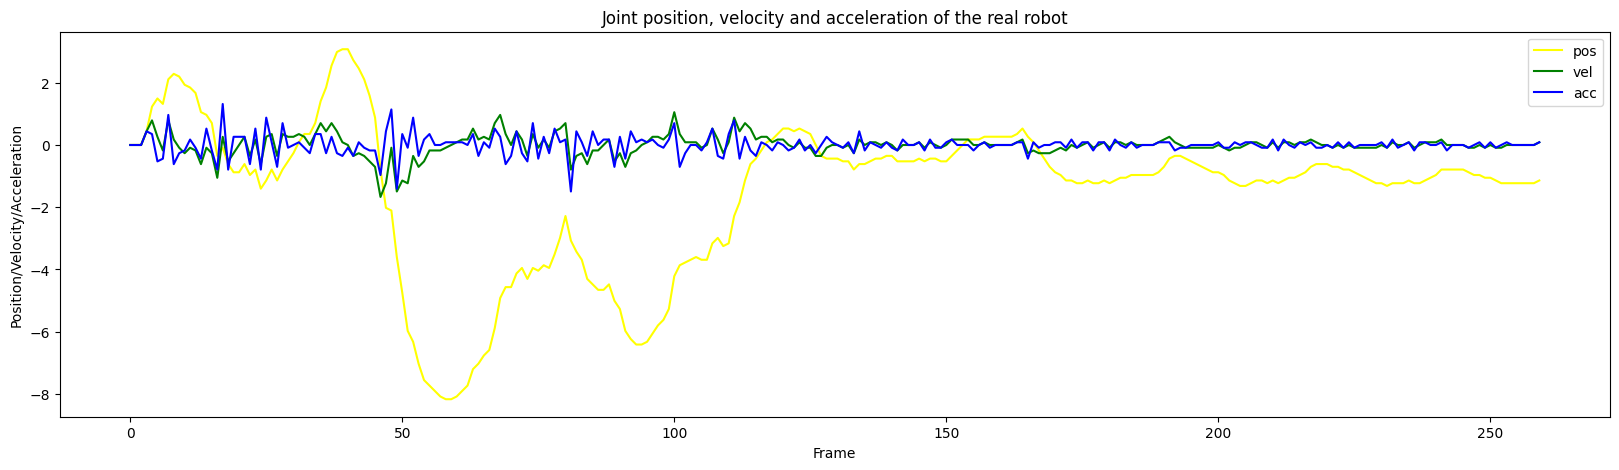

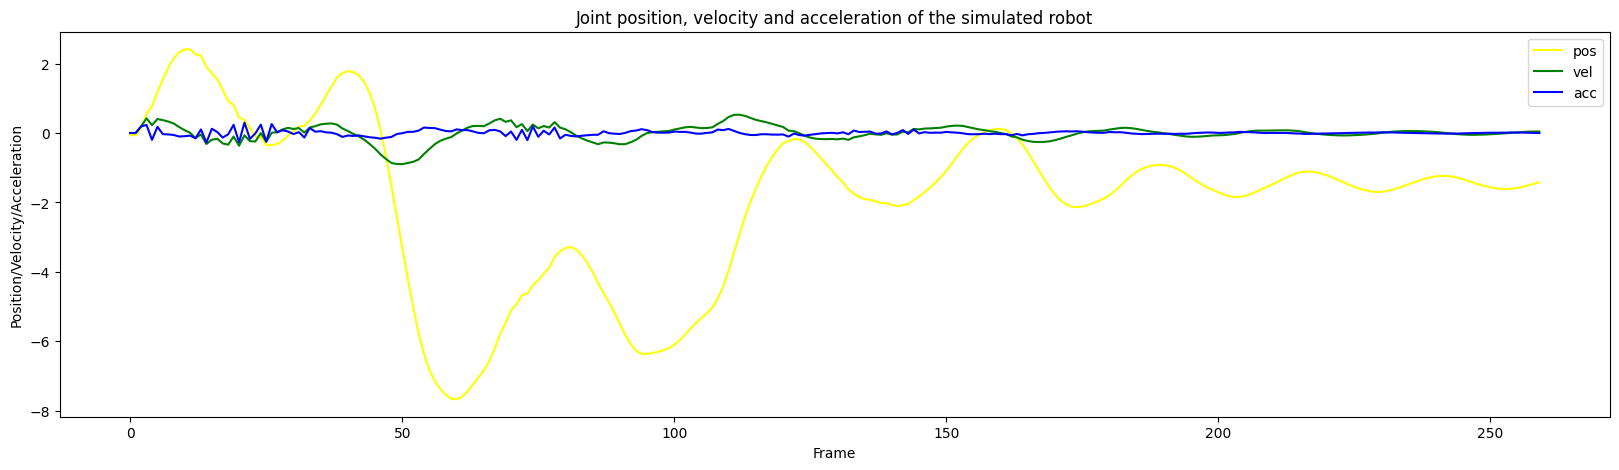

In [2]:
def show_raw_values():
    action = "kick"
    index_in_list = 1
    joint = "lAnkleRoll"
    start_frame = 0
    end_frame = -1
    line_type = '-'

    gap_object = gap_handler.get_at(action, index_in_list)
    gap_object.load()
    pos_extraction = gap_object.get_pos_extraction(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    vel_extraction = gap_object.get_vel_extraction(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    acc_extraction = gap_object.get_acc_extraction(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    pos_replay = gap_object.get_pos_replay(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    vel_replay = gap_object.get_vel_replay(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    acc_replay = gap_object.get_acc_replay(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    gap_object.unload()

    plt.figure(figsize=(20, 5))
    plt.title("Joint position, velocity and acceleration of the real robot")
    plt.xlabel("Frame")
    plt.ylabel("Position/Velocity/Acceleration")
    plt.plot(range(len(pos_extraction[joint])), pos_extraction[joint],line_type, color="yellow", label="pos")
    plt.plot(range(len(vel_extraction[joint])), vel_extraction[joint],line_type, color="green", label="vel")
    plt.plot(range(len(acc_extraction[joint])), acc_extraction[joint],line_type, color="blue", label="acc")
    plt.legend()
    plt.show()
    plt.figure(figsize=(20, 5))
    plt.title("Joint position, velocity and acceleration of the simulated robot")
    plt.xlabel("Frame")
    plt.ylabel("Position/Velocity/Acceleration")
    plt.plot(range(len(pos_replay[joint])), pos_replay[joint],line_type, color="yellow", label="pos")
    plt.plot(range(len(vel_replay[joint])), vel_replay[joint],line_type, color="green", label="vel")
    plt.plot(range(len(acc_replay[joint])), acc_replay[joint], line_type, color="blue", label="acc")
    plt.legend()
    plt.show()
show_raw_values()

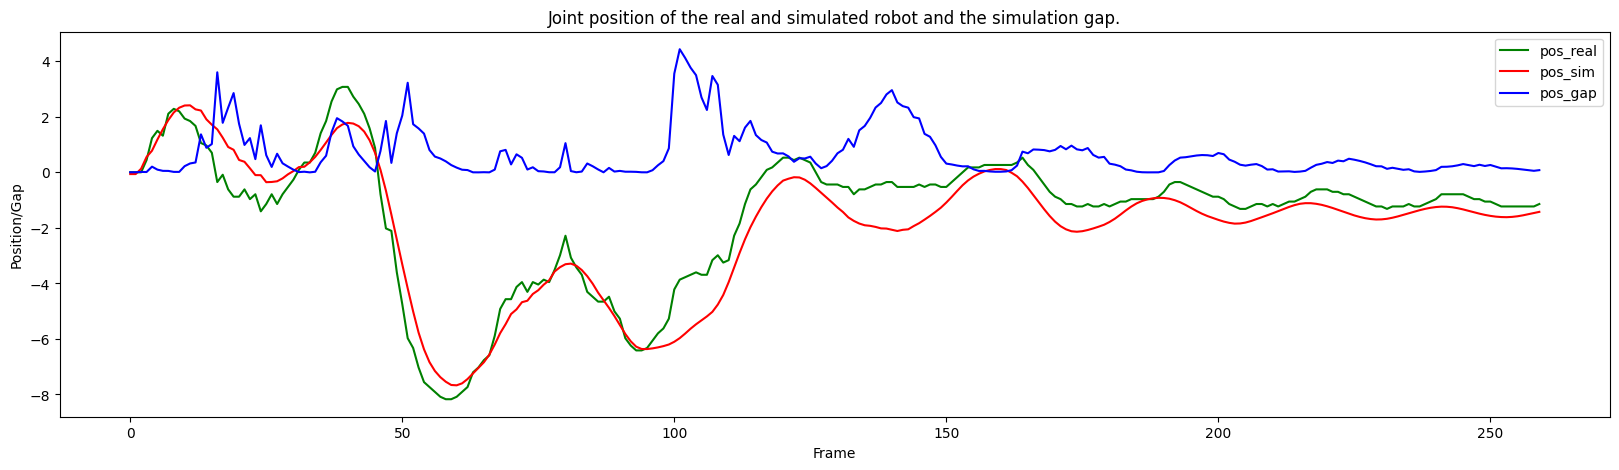

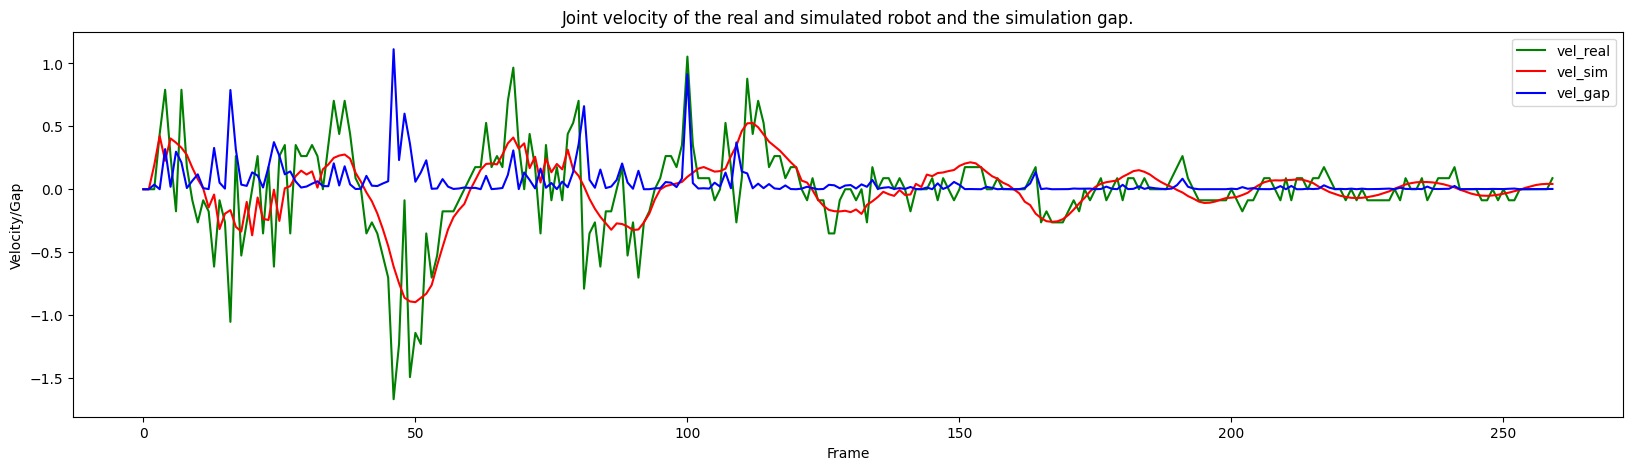

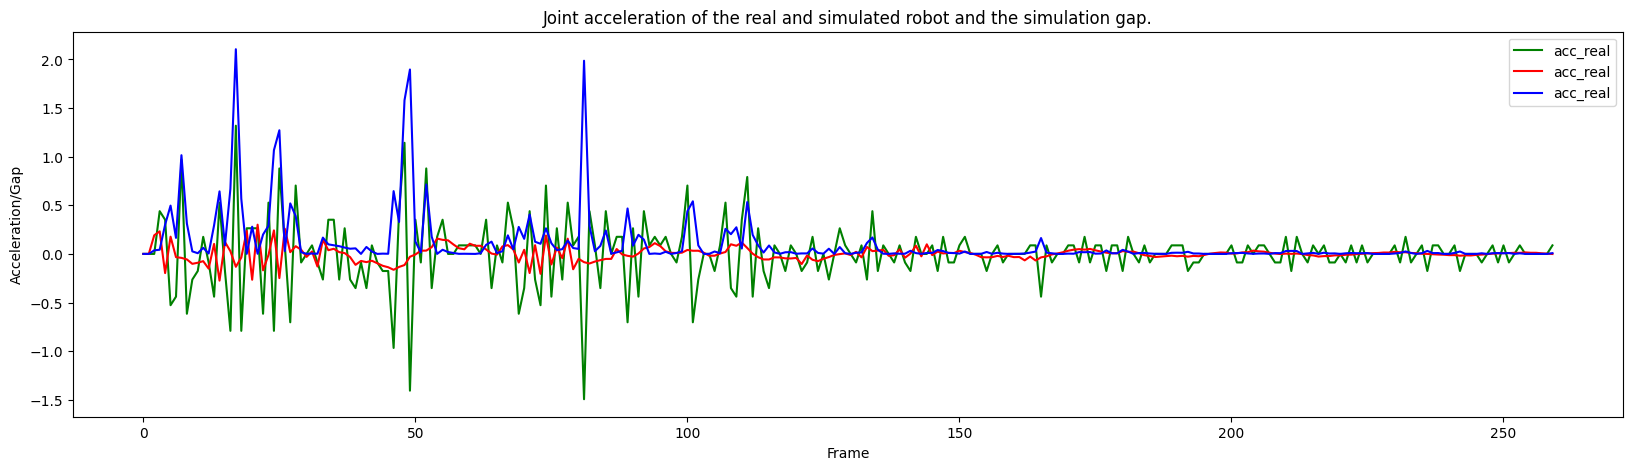

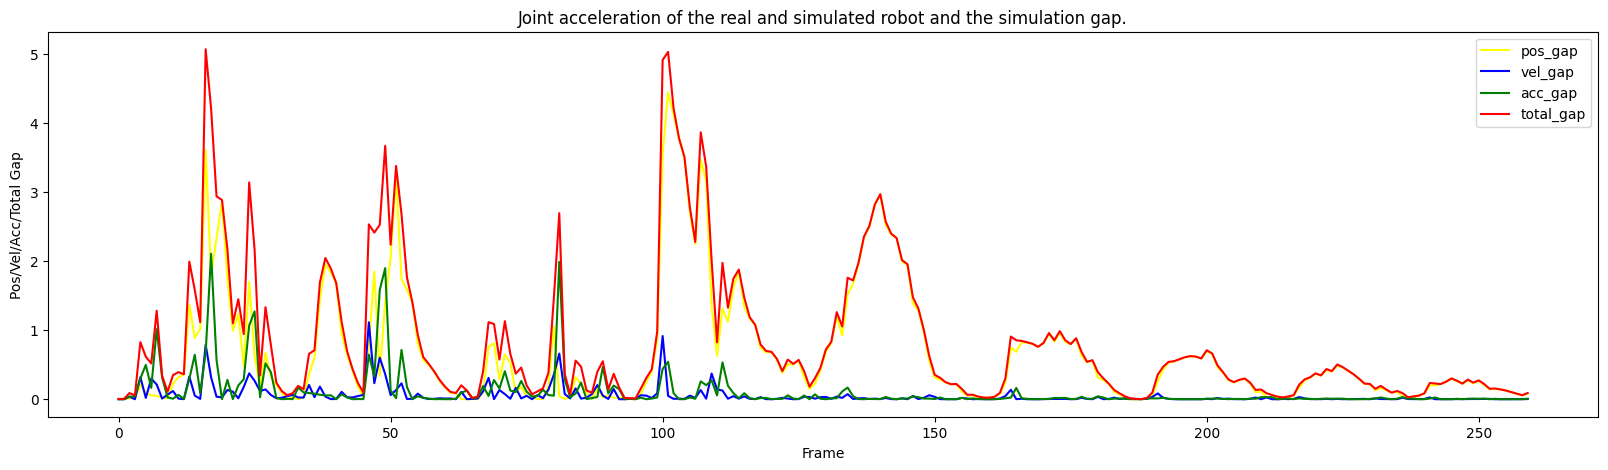

In [3]:
def show_single_gap():
    action = "kick"
    index_in_list = 1
    joint = "lAnkleRoll"
    start_frame = 0
    end_frame = -1
    line_type = '-'

    gap_object = gap_handler.get_at(action, index_in_list)
    gap_object.load()
    pos_extraction = gap_object.get_pos_extraction(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    vel_extraction = gap_object.get_vel_extraction(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    acc_extraction = gap_object.get_acc_extraction(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    pos_replay = gap_object.get_pos_replay(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    vel_replay = gap_object.get_vel_replay(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    acc_replay = gap_object.get_acc_replay(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    pos_gap = gap_object.get_pos_gap(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    vel_gap = gap_object.get_vel_gap(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    acc_gap = gap_object.get_acc_gap(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    total_gap = gap_object.get_total_gap(hinge_names=[joint], start_frame=start_frame, end_frame=end_frame)
    gap_object.unload()

    plt.figure(figsize=(20, 5))
    plt.title("Joint position of the real and simulated robot and the simulation gap.")
    plt.xlabel("Frame")
    plt.ylabel("Position/Gap")
    plt.plot(range(len(pos_extraction[joint])), pos_extraction[joint],line_type, color="green", label="pos_real")
    plt.plot(range(len(pos_replay[joint])), pos_replay[joint],line_type, color="red", label="pos_sim")
    plt.plot(range(len(pos_gap[joint])), pos_gap[joint],line_type, color="blue", label="pos_gap")
    plt.legend()
    plt.show()

    plt.figure(figsize=(20, 5))
    plt.title("Joint velocity of the real and simulated robot and the simulation gap.")
    plt.xlabel("Frame")
    plt.ylabel("Velocity/Gap")
    plt.plot(range(len(vel_extraction[joint])), vel_extraction[joint],line_type, color="green", label="vel_real")
    plt.plot(range(len(vel_replay[joint])), vel_replay[joint],line_type, color="red", label="vel_sim")
    plt.plot(range(len(vel_gap[joint])), vel_gap[joint],line_type, color="blue", label="vel_gap")
    plt.legend()
    plt.show()

    plt.figure(figsize=(20, 5))
    plt.title("Joint acceleration of the real and simulated robot and the simulation gap.")
    plt.xlabel("Frame")
    plt.ylabel("Acceleration/Gap")
    plt.plot(range(len(acc_extraction[joint])), acc_extraction[joint],line_type, color="green", label="acc_real")
    plt.plot(range(len(acc_replay[joint])), acc_replay[joint], line_type, color="red", label="acc_real")
    plt.plot(range(len(acc_gap[joint])), acc_gap[joint], line_type, color="blue", label="acc_real")
    plt.legend()
    plt.show()

    plt.figure(figsize=(20, 5))
    plt.title("Joint acceleration of the real and simulated robot and the simulation gap.")
    plt.xlabel("Frame")
    plt.ylabel("Pos/Vel/Acc/Total Gap")
    plt.plot(range(len(pos_gap[joint])), pos_gap[joint], line_type, color="yellow", label="pos_gap")
    plt.plot(range(len(vel_gap[joint])), vel_gap[joint], line_type, color="blue", label="vel_gap")
    plt.plot(range(len(acc_gap[joint])), acc_gap[joint], line_type, color="green", label="acc_gap")
    plt.plot(range(len(total_gap[joint])), total_gap[joint], line_type, color="red", label="total_gap")
    plt.legend()
    plt.show()

show_single_gap()

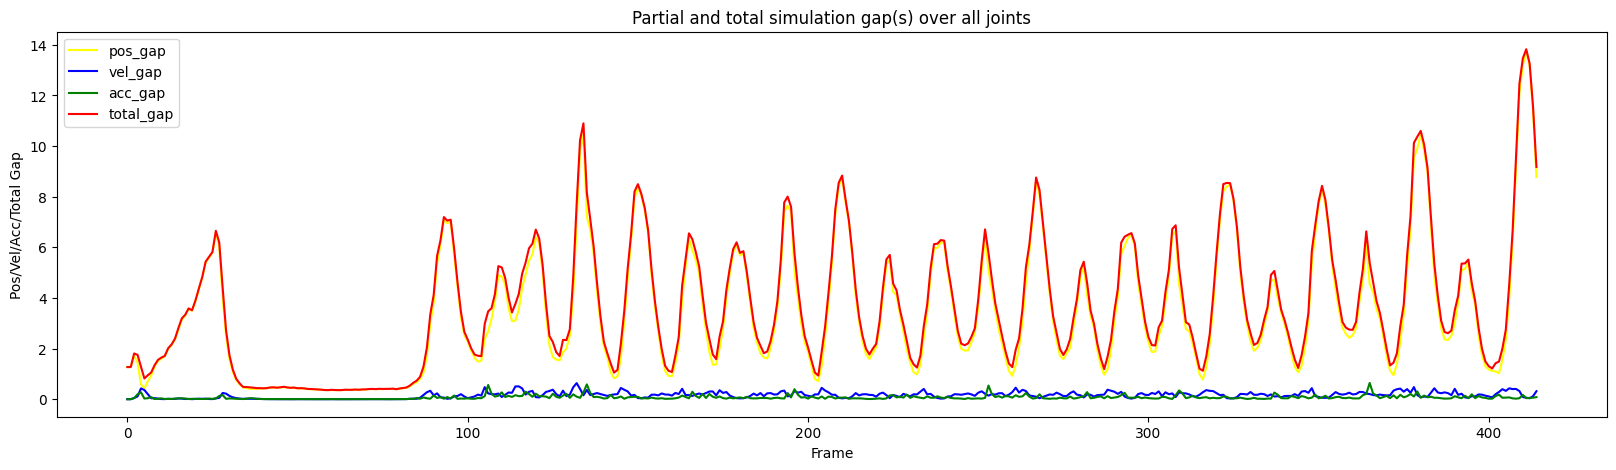

In [4]:
def show_avg_frame_gap():
    action = "walk"
    index_in_list = 1
    start_frame = 0
    end_frame = -1
    line_type = '-'
    gap_object = gap_handler.get_at(action, index_in_list)
    gap_object.load()
    pos_gap = gap_object.get_pos_gap_avg_for_frames(start_frame=start_frame, end_frame=end_frame)
    vel_gap = gap_object.get_vel_gap_avg_for_frames(start_frame=start_frame, end_frame=end_frame)
    acc_gap = gap_object.get_acc_gap_avg_for_frames(start_frame=start_frame, end_frame=end_frame)
    total_gap = gap_object.get_total_gap_avg_for_frames(start_frame=start_frame, end_frame=end_frame)
    gap_object.unload()

    plt.figure(figsize=(20, 5))
    plt.title("Partial and total simulation gap(s) over all joints")
    plt.xlabel("Frame")
    plt.ylabel("Pos/Vel/Acc/Total Gap")
    plt.plot(range(len(pos_gap)), pos_gap, line_type, color="yellow", label="pos_gap")
    plt.plot(range(len(vel_gap)), vel_gap, line_type, color="blue", label="vel_gap")
    plt.plot(range(len(acc_gap)), acc_gap, line_type, color="green", label="acc_gap")
    plt.plot(range(len(total_gap)), total_gap, line_type, color="red", label="total_gap")
    plt.legend()
    plt.show()
show_avg_frame_gap()

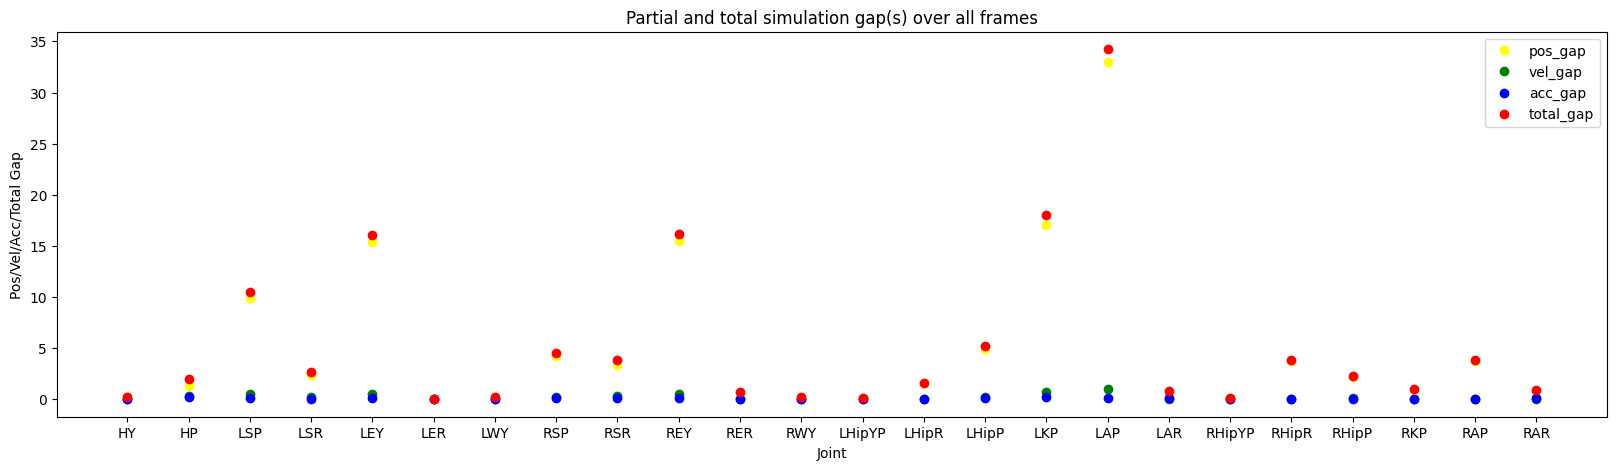

In [7]:
def show_avg_joint_gap():
    action = "kick"
    index_in_list = 1
    line_type = 'o'
    gap_object = gap_handler.get_at(action, index_in_list)
    gap_object.load()
    pos_gap = gap_object.get_pos_gap_avg_for_joints()
    vel_gap = gap_object.get_vel_gap_avg_for_joints()
    acc_gap = gap_object.get_acc_gap_avg_for_joints()
    total_gap = gap_object.get_total_gap_avg_for_joints()
    gap_object.unload()

    plt.figure(figsize=(20, 5))
    plt.title("Partial and total simulation gap(s) over all frames")
    plt.xlabel("Joint")
    plt.ylabel("Pos/Vel/Acc/Total Gap")
    plt.plot([HINGE_SHORT[joint_name] for joint_name in pos_gap.keys()], pos_gap.values(),line_type, color="yellow", label="pos_gap")
    plt.plot([HINGE_SHORT[joint_name] for joint_name in vel_gap.keys()], vel_gap.values(),line_type, color="green", label="vel_gap")
    plt.plot([HINGE_SHORT[joint_name] for joint_name in acc_gap.keys()], acc_gap.values(), line_type, color="blue", label="acc_gap")
    plt.plot([HINGE_SHORT[joint_name] for joint_name in total_gap.keys()], total_gap.values(), line_type, color="red", label="total_gap")
    plt.legend()
    plt.show()
show_avg_joint_gap()

In [ ]:
def show_avg_joint_gap():
    action = "kick"
    index_in_list = 1
    line_type = 'o'
    gap_object = gap_handler.get_at(action, index_in_list)
    gap_object.load()
    pos_gap = gap_object.get_pos_gap_avg_for_joints()
    vel_gap = gap_object.get_vel_gap_avg_for_joints()
    acc_gap = gap_object.get_acc_gap_avg_for_joints()
    total_gap = gap_object.get_total_gap_avg_for_joints()
    gap_object.unload()

    plt.figure(figsize=(20, 5))
    plt.title("Partial and total simulation gap(s) over all frames")
    plt.xlabel("Joint")
    plt.ylabel("Pos/Vel/Acc/Total Gap")
    plt.plot([HINGE_SHORT[joint_name] for joint_name in pos_gap.keys()], pos_gap.values(),line_type, color="yellow", label="pos_gap")
    plt.plot([HINGE_SHORT[joint_name] for joint_name in vel_gap.keys()], vel_gap.values(),line_type, color="green", label="vel_gap")
    plt.plot([HINGE_SHORT[joint_name] for joint_name in acc_gap.keys()], acc_gap.values(), line_type, color="blue", label="acc_gap")
    plt.plot([HINGE_SHORT[joint_name] for joint_name in total_gap.keys()], total_gap.values(), line_type, color="red", label="total_gap")
    plt.legend()
    plt.show()
show_avg_joint_gap()

{'headYaw': 0.15811551909012814, 'headPitch': 1.4919182957482242, 'lShoulderPitch': 11.10343355005197, 'lShoulderRoll': 2.8106020159902525, 'lElbowYaw': 17.26897854219595, 'lElbowRoll': 0.031796963271896725, 'lWristYaw': 0.2511837662303497, 'rShoulderPitch': 4.897360115053223, 'rShoulderRoll': 2.954515393073318, 'rElbowYaw': 17.587222049355393, 'rElbowRoll': 0.6734599559366624, 'rWristYaw': 0.22361514444724187, 'lHipYawPitch': 0.17162650998054566, 'lHipRoll': 1.028850107721239, 'lHipPitch': 4.872797775032847, 'lKneePitch': 18.653554794948665, 'lAnklePitch': 36.3840469632138, 'lAnkleRoll': 0.5562108310538131, 'rHipYawPitch': 0.17149929566069488, 'rHipRoll': 3.2853644933610417, 'rHipPitch': 3.0040644719255165, 'rKneePitch': 0.9269264276016895, 'rAnklePitch': 4.800236458809322, 'rAnkleRoll': 0.799070938262874}


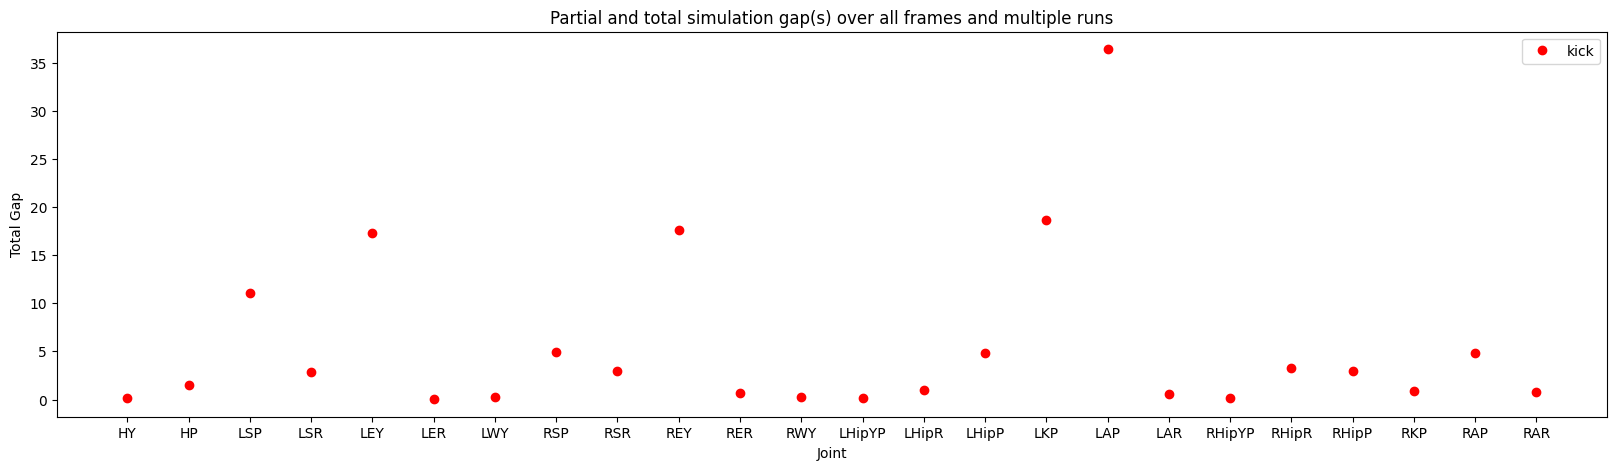

In [6]:
def show_avg_frame_gap_for_action():
    action = "kick"
    line_type = 'o'
    plt.figure(figsize=(20, 5))
    plt.title("Partial and total simulation gap(s) over all frames and multiple runs")
    plt.xlabel("Joint")
    plt.ylabel("Total Gap")
    gap = gap_handler.get_avg_for_joints(action)
    print(gap)
    plt.plot([HINGE_SHORT[joint_name] for joint_name in gap.keys()], gap.values(),line_type, color="red", label=action)
    plt.legend()
    plt.show()
show_avg_frame_gap_for_action()